# Taller - Extracción de Caracteristicas con SIFT y ORB

Notebook en Python para extraer y comparar caracteristicas con Harris, SIFT y ORB.

## 1. Configurar dependencias y rutas de trabajo

In [10]:
import os
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt

MEDIA_DIR = os.path.join("..", "media")
os.makedirs(MEDIA_DIR, exist_ok=True)

BASE_IMAGE_PATH = os.path.join(MEDIA_DIR, "base_scene.png")

## 2. Cargar imagen de prueba y preprocesar

Se genera una imagen sintetica si no existe, luego se carga desde disco y se convierte a escala de grises.

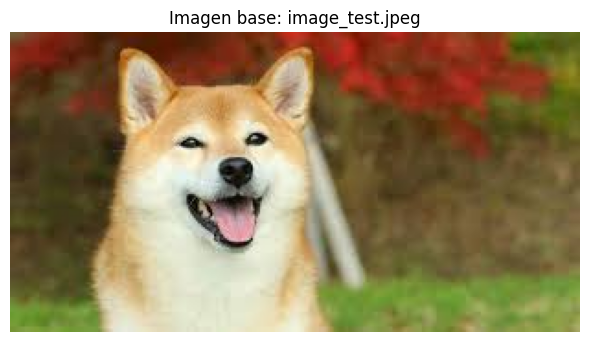

In [11]:
user_image_name = "image_test.jpeg"

candidate_paths = [
    os.path.join(os.getcwd(), user_image_name),
    os.path.join(os.getcwd(), "python", user_image_name),
]

base_path = None
for candidate in candidate_paths:
    if os.path.exists(candidate):
        base_path = candidate
        break

if base_path is None:
    raise FileNotFoundError(
        "No se encontro image_test.jpeg. Colocala en la carpeta python y vuelve a ejecutar."
    )

img_bgr = cv2.imread(base_path)
if img_bgr is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {base_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title(f"Imagen base: {os.path.basename(base_path)}")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, "base_scene_display.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Detección de esquinas con Harris

Se aplica Harris Corner Detector y se ajustan parametros basicos.

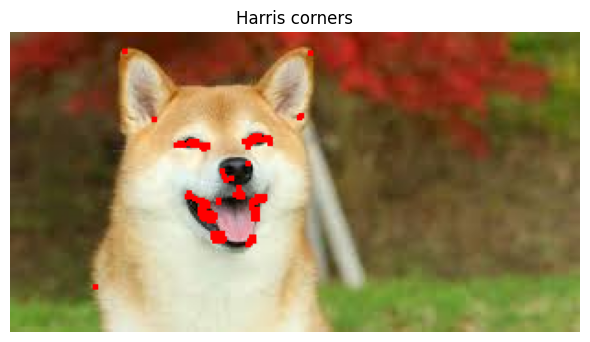

In [12]:
block_size = 2
ksize = 3
k = 0.04

gray_float = np.float32(img_gray)
harris = cv2.cornerHarris(gray_float, block_size, ksize, k)
harris = cv2.dilate(harris, None)

threshold = 0.01 * harris.max()
harris_vis = img_rgb.copy()
harris_vis[harris > threshold] = [255, 0, 0]

plt.figure(figsize=(6, 4))
plt.imshow(harris_vis)
plt.title("Harris corners")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, "harris_corners.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. SIFT: detección de keypoints y descriptores

Se crean keypoints con escala y orientacion. Se guardan visualizaciones ricas.

SIFT keypoints: 111


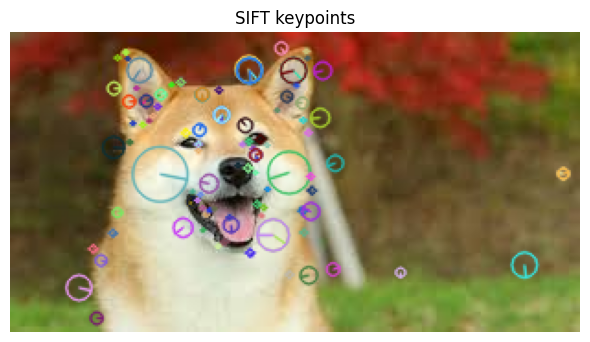

In [13]:
if not hasattr(cv2, "SIFT_create"):
    raise RuntimeError("SIFT no esta disponible. Instala opencv-contrib-python.")

sift = cv2.SIFT_create()
kp_sift, des_sift = sift.detectAndCompute(img_gray, None)

sift_vis = cv2.drawKeypoints(
    img_rgb,
    kp_sift,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

print(f"SIFT keypoints: {len(kp_sift)}")

plt.figure(figsize=(6, 4))
plt.imshow(sift_vis)
plt.title("SIFT keypoints")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, "sift_keypoints.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. ORB: detección de keypoints y descriptores

Se crea ORB y se visualizan los keypoints detectados.

ORB keypoints (top 200): 200


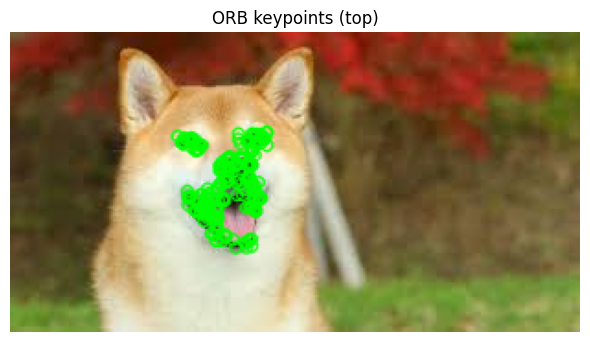

In [14]:
orb = cv2.ORB_create(nfeatures=1000)
kp_orb, des_orb = orb.detectAndCompute(img_gray, None)

top_k = 200
kp_orb = sorted(kp_orb, key=lambda kp: kp.response, reverse=True)[:top_k]
kp_orb, des_orb = orb.compute(img_gray, kp_orb)

orb_vis = cv2.drawKeypoints(
    img_rgb,
    kp_orb,
    None,
    color=(0, 255, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT,
 )

print(f"ORB keypoints (top {top_k}): {len(kp_orb)}")

plt.figure(figsize=(6, 4))
plt.imshow(orb_vis)
plt.title("ORB keypoints (top)")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, "orb_keypoints.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Comparación SIFT vs ORB (tiempo y cantidad de keypoints)

Se miden tiempos promedio y se comparan cantidades de keypoints.

Comparacion de rendimiento
SIFT  -> keypoints:  111 | tiempo: 3.40 ms (std 0.34)
ORB   -> keypoints:  200 | tiempo: 0.76 ms (std 0.05)


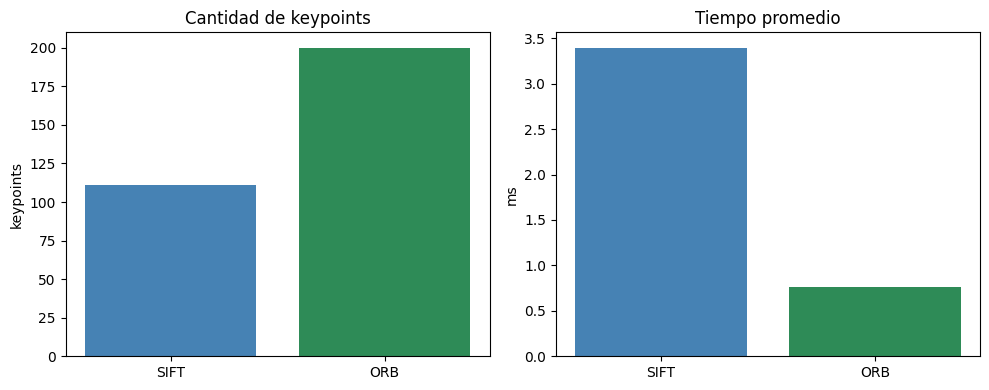

In [15]:
def benchmark(detector, image_gray, runs=10):
    timings = []
    for _ in range(runs):
        start = time.perf_counter()
        detector.detectAndCompute(image_gray, None)
        timings.append(time.perf_counter() - start)
    return float(np.mean(timings)), float(np.std(timings))

sift_time_mean, sift_time_std = benchmark(sift, img_gray)
orb_time_mean, orb_time_std = benchmark(orb, img_gray)

print("Comparacion de rendimiento")
print(f"SIFT  -> keypoints: {len(kp_sift):4d} | tiempo: {sift_time_mean*1000:.2f} ms (std {sift_time_std*1000:.2f})")
print(f"ORB   -> keypoints: {len(kp_orb):4d} | tiempo: {orb_time_mean*1000:.2f} ms (std {orb_time_std*1000:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["SIFT", "ORB"], [len(kp_sift), len(kp_orb)], color=["steelblue", "seagreen"])
axes[0].set_title("Cantidad de keypoints")
axes[0].set_ylabel("keypoints")

axes[1].bar(["SIFT", "ORB"], [sift_time_mean * 1000, orb_time_mean * 1000], color=["steelblue", "seagreen"])
axes[1].set_title("Tiempo promedio")
axes[1].set_ylabel("ms")

plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, "comparison_time_keypoints.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Robustez ante rotación, escala e iluminación

Se generan transformaciones y se comparan los keypoints detectados.

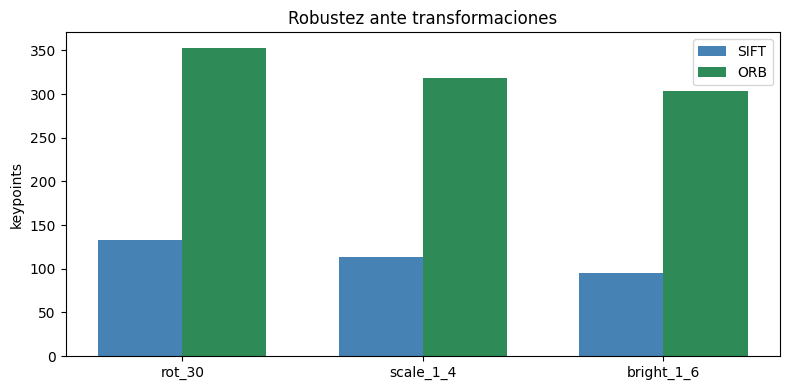

In [16]:
def rotate_image(img, angle_deg):
    h, w = img.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    return cv2.warpAffine(img, matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)


def scale_image(img, scale):
    h, w = img.shape[:2]
    resized = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)
    out = np.full_like(img, 20)

    rh, rw = resized.shape[:2]
    if scale >= 1.0:
        y0 = (rh - h) // 2
        x0 = (rw - w) // 2
        out = resized[y0 : y0 + h, x0 : x0 + w]
    else:
        y0 = (h - rh) // 2
        x0 = (w - rw) // 2
        out[y0 : y0 + rh, x0 : x0 + rw] = resized

    return out


def adjust_brightness(img, gamma):
    inv = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

variants = {
    "rot_30": rotate_image(img_bgr, 30),
    "scale_1_4": scale_image(img_bgr, 1.4),
    "bright_1_6": adjust_brightness(img_bgr, 1.6),
}

variant_names = []
sift_counts = []
orb_counts = []

for name, img_variant in variants.items():
    gray = cv2.cvtColor(img_variant, cv2.COLOR_BGR2GRAY)
    kp_s, _ = sift.detectAndCompute(gray, None)
    kp_o, _ = orb.detectAndCompute(gray, None)

    variant_names.append(name)
    sift_counts.append(len(kp_s))
    orb_counts.append(len(kp_o))

x = np.arange(len(variant_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, sift_counts, width, label="SIFT", color="steelblue")
ax.bar(x + width / 2, orb_counts, width, label="ORB", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(variant_names)
ax.set_ylabel("keypoints")
ax.set_title("Robustez ante transformaciones")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, "robustness_keypoints.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Visualización avanzada y guardado en media/

Se comparan visualmente SIFT y ORB lado a lado.

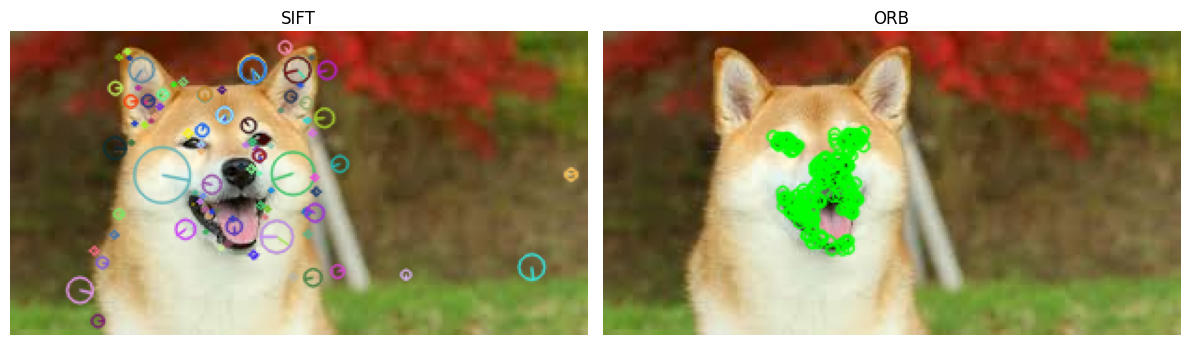

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(sift_vis)
axes[0].set_title("SIFT")
axes[0].axis("off")

axes[1].imshow(orb_vis)
axes[1].set_title("ORB")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, "sift_vs_orb_side_by_side.png"), dpi=150, bbox_inches="tight")
plt.show()